### Import the libraries

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer

# Load built-in dataset
df = sns.load_dataset('planets')

### Preview the variable

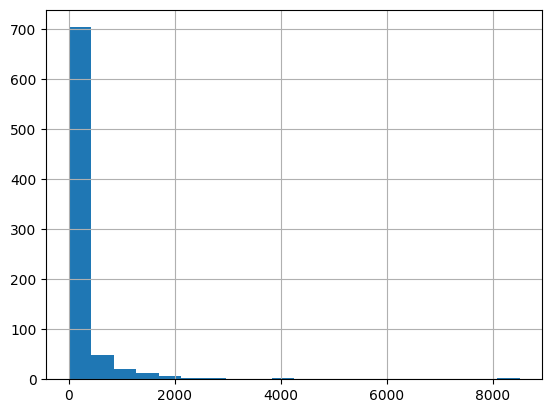

In [32]:
# Plot a histogram to visualize the distribution for the variable
df['distance'].hist(bins=20)
plt.show()

### Calculate value for skewness

In [33]:
print(f"Original Skew: {df['distance'].skew()}")

Original Skew: 7.362539120859176


### Impute data based on skewness of the variable

In [34]:
imputer = SimpleImputer(strategy='median')
df['distance'] = imputer.fit_transform(df[['distance']])

### Transform the data

Transformed Skew: -0.034103332178510824


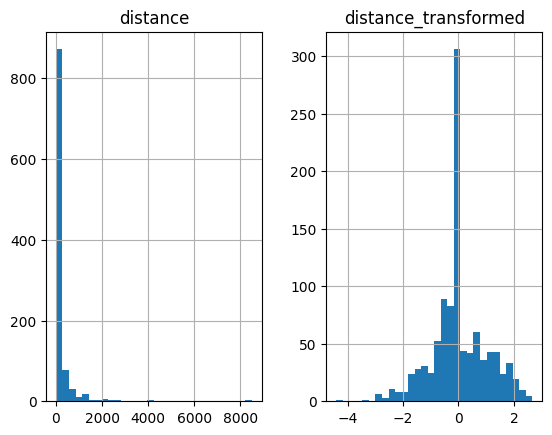

In [35]:
# 3. Transformation: Applying Yeo-Johnson
# PowerTransformer standardizes and transforms to Gaussian-like
pt = PowerTransformer(method='yeo-johnson') 
df['distance_transformed'] = pt.fit_transform(df[['distance']])

print(f"Transformed Skew: {pd.Series(df['distance_transformed']).skew()}")

# Visuale the results
df[['distance', 'distance_transformed']].hist(bins=30)
plt.show()

### Additional transformation method

In [36]:
# 1. Box-Cox: Requires all input values to be STRICTLY POSITIVE (> 0).
# If your data has 0s or negative numbers, this will throw an error.
# pt_boxcox = PowerTransformer(method='box-cox')
# df['dist_boxcox'] = pt_boxcox.fit_transform(df[['distance']])